## House Prices - Advanced Regression Techniques <br> 房价——高级回归技术

### Goal 目标

It is your job to predict the sales price for each house. For each Id in the test set, you must predict the value of the SalePrice variable.
你的任务是预测每栋房屋的售价。对于测试集中的每个 ID，你必须预测 SalePrice 变量的值。

API key = KGAT_53788d07f5f72126b602b031635897c1

## 1 Packages and data load (5mins) 库与数据加载

- [x] Import packages
- [x] Set directories
- [x] Load dataset
- [x] Preview data

In [140]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# config
sns.set_theme(style="whitegrid")

In [2]:
DATA_DIR = Path(r"house-prices")

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
description_path = DATA_DIR / "data_description.txt"

print("当前目录:", DATA_DIR.resolve())
print("train.csv:", train_path.exists())
print("test.csv :", test_path.exists())
print("description:", description_path.exists())

当前目录: /Users/2398768715qq.com/GitHub/ITMO-MA/EnterExam/ai/Practice/S1-1/house-prices
train.csv: True
test.csv : True
description: True


In [3]:
# NA_VALUES = []

train = pd.read_csv(train_path,keep_default_na=True) # na_values=NA_VALUES
test = pd.read_csv(test_path, keep_default_na=True) # na_values=NA_VALUES

In [42]:
print("train shape:", train.shape)
print("test shape :", test.shape)

display(train.head())
display(test.head())

train shape: (1460, 81)
test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## 2 Data quality analysis (10 mins) 数据质量检查

- [x] Missing: missing count, missing rate
  缺失值异常：缺失数量、缺失率
- [x] Duplicated: duplicated rows, duplicated ids, duplicated entities
  重复异常：重复值、重复ID、重复实体
- [x] Outliers: distribution, extreme value
  离群异常：离群分布、极端值
- [x] Logic Inconsistent: time logic, quantity-existence, category-numeric, total-subtotal
  逻辑一致性异常：时间逻辑、数量和存在关系、类别和数值冲突、总量分量关系等
- [x] Invalidation: invalid range, invalid category, impossible value
  非法值异常：非法范围、非法类别等
- [ ] Formatting: case inconsistency, spacing, typos, empty strings, date/text format
  数据格式异常：拼写错误、大小写不一致、多余空格、空字符串等

### 2.1 Data understanding 数据理解

In [5]:
print("--- ID/Target ---")
ID_COL = "Id"
TARGET_COL = "SalePrice"
print("Target:", TARGET_COL)
print("Target dtype:", train[TARGET_COL].dtype)

print("\n--- Columns Classify ---")
NUM_COL = train.select_dtypes(include=[np.number]).columns
OBJ_COL = train.select_dtypes(exclude=[np.number]).columns
print("Numerical Columns:", NUM_COL.tolist())
print("\nObjective Columns:", OBJ_COL.tolist())

print("\n--- train.info() ---")
print(train.info())

--- ID/Target ---
Target: SalePrice
Target dtype: int64

--- Columns Classify ---
Numerical Columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Objective Columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',

### 2.2 Missing value check 缺失值检查

- [x] missing count
- [x] missing rate

**注意：缺失值不一定代表错误。**

House Prices 中某些空值实际上可能意味着“没有该设施”，例如没有车库、地下室、泳池等。因此真正处理前应该阅读 `data_description.txt`。

| Missing rate | Handle strategy            |
|--------------|----------------------------|
| <0.1%        | 可以考虑直接删除对应行                |
| 0.1% ~ 5%    | 优先考虑简单填充                   |
| 5% ~ 30%     | 根据特征语义选择填充策略               |
| >30%         | 重点判断 NA 是否具有业务含义，不能仅凭缺失率决定 |

In [253]:
def missing_report(
        df: pd.DataFrame,
        columns=None,
        missing_only=True,
        sort_by="missing_rate",
        ascending=False):

    if columns is not None:
        df = df[columns]

    # 生成缺失值报告表格
    report = pd.DataFrame({
        "dtype": df.dtypes,
        "missing_count": df.isna().sum(),
        "missing_rate": df.isna().mean()
    })

    # 过滤无缺失值的特征
    if missing_only:
        report = report[report["missing_count"] > 0]

    return report.sort_values(by=sort_by, ascending=ascending)

# 排序后输出
with pd.option_context("display.max_rows", None,"display.max_columns", None):
    display(missing_report(train))

,dtype,missing_count,missing_rate
PoolQC,object,1453,0.995205
MiscFeature,object,1406,0.963014
Alley,object,1369,0.937671
Fence,object,1179,0.807534
MasVnrType,object,872,0.597260
FireplaceQu,object,690,0.472603
LotFrontage,float64,259,0.177397
GarageType,object,81,0.055479
GarageYrBlt,float64,81,0.055479
GarageFinish,object,81,0.055479


### 2.3 Duplication check 重复值检查

- [x] 总重复行检查
- [x] ID 重复行检查
- [x] ID 部分缺失下的重复检查

In [281]:
ID_COL = "Id"

print("Total duplicated rows:", train.duplicated().sum())

print("Duplicated rows num by Id:", train[ID_COL].duplicated(keep=False).sum())
print("Unique Id num:", train[ID_COL].nunique())
print("Total rows num:", len(train))

dup_ids = train.loc[train[ID_COL].duplicated(keep=False), ID_COL]
display(train[train[ID_COL].isin(dup_ids)].sort_values(ID_COL).head(20))


Total duplicated rows: 0
Duplicated rows num by Id: 0
Unique Id num: 1460
Total rows num: 1460


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


Total duplicated entitis: 0


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [280]:
# 自定义可唯一确定实体的 Columns 组合
# IDENTIFY_COLS = [
#     "Neighborhood",
#     "GrLivArea",
#     "YearBuilt",
#     "OverallQual"]

# 自定义不影响唯一实体确定的 Columns 组合
IDENTIFY_COLS_EXCLUDE = [
    ID_COL,
    TARGET_COL,
]
IDENTIFY_COLS = train.drop(columns=IDENTIFY_COLS_EXCLUDE).columns.tolist()

def duplicated_entities_report(
        df: pd.DataFrame,
        identify_columns=None,):

    print("Total duplicated entities:", df.duplicated(subset=identify_columns, keep=False).sum())
    duplicated_mask = df.duplicated(subset=identify_columns, keep=False)

    return df[duplicated_mask]

display(duplicated_entities_report(train, IDENTIFY_COLS))

Total duplicated entitis: 0


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


### 2.4 Outliers check 离群值检查

- Numeric outlier
  - outlier count
  - outlier rate
- Categoric outlier
  - unique count
  - top frequency

In [95]:
print("--- 数值变量统计 ---")
display(train.describe())

--- 数值变量统计 ---


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [93]:
# 离群值报告分析
outliers = []

for col in NUM_COL.drop([ID_COL, TARGET_COL]):
    data = train[col].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((data < lower) | (data > upper)).sum()
    outlier_rate = outlier_count / len(data)

    outliers.append({
            "column": col,
            "count": len(data),
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": outlier_count,
            "outlier_rate": outlier_rate
        })

outlier_report = pd.DataFrame(outliers).set_index("column")
outlier_report.index.name = None
outlier_report = outlier_report[outlier_report["outlier_count"] > 0]

display(outlier_report.sort_values(by="outlier_rate", ascending=False).T)

,EnclosedPorch,BsmtFinSF2,OverallCond,ScreenPorch,LotFrontage,MSSubClass,MasVnrArea,BsmtHalfBath,OpenPorchSF,LotArea,...,GarageArea,1stFlrSF,YearBuilt,PoolArea,BsmtFinSF1,GarageCars,Fireplaces,OverallQual,2ndFlrSF,BsmtFullBath
count,1460.000000,1460.000000,1460.000000,1460.000000,1201.000000,1460.000000,1452.000000,1460.000000,1460.00000,1460.00000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.00000,1460.00000,1460.000000
lower_bound,0.000000,0.000000,3.500000,0.000000,27.500000,-55.000000,-249.000000,0.000000,-102.00000,1481.50000,...,-27.750000,118.125000,1885.000000,0.000000,-1068.375000,-0.500000,-1.500000,2.00000,-1092.00000,-1.500000
upper_bound,0.000000,0.000000,7.500000,0.000000,111.500000,145.000000,415.000000,0.000000,170.00000,17673.50000,...,938.250000,2155.125000,2069.000000,0.000000,1780.625000,3.500000,2.500000,10.00000,1820.00000,2.500000
outlier_count,208.000000,167.000000,125.000000,116.000000,88.000000,103.000000,96.000000,82.000000,77.00000,69.00000,...,21.000000,20.000000,7.000000,7.000000,7.000000,5.000000,5.000000,2.00000,2.00000,1.000000
outlier_rate,0.142466,0.114384,0.085616,0.079452,0.073272,0.070548,0.066116,0.056164,0.05274,0.04726,...,0.014384,0.013699,0.004795,0.004795,0.004795,0.003425,0.003425,0.00137,0.00137,0.000685


In [92]:
print("--- 类别变量统计 ---")
display(train.describe(exclude=[np.number]))
# display(train.describe(include=["object"]))

--- 类别变量统计 ---


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


### 2.5 Logic Inconsistency/Invalid Value 逻辑不一致/非法值

- Date/time logic
- Quantity-existence
- Category-numeric
- Total-subtotal

In [244]:
RULES = [
    ["Built year in future:", lambda df: df['YearBuilt'] > 2009],
]

def check_rule(df, rule, n_samples=5):

    name, condition = rule
    violations = df[condition]

    print(name, len(violations))

    if len(violations) > 0:
        display(violations.head(n_samples))

    return violations

for RULE in RULES:
    check_rule(train, RULE, len(train))

Built year in future: 1


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
378,379,20,RL,88.0,11394,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,New,Partial,394432


### 2.6 Format Issues

- dtype
- String Format
- Date/Time
- Spacing
- Encoding

In [240]:
for col in OBJ_COL:
    print(col, train[col].nunique(), train[col].unique())

MSZoning 5 ['RL' 'RM' 'C (all)' 'FV' 'RH']
Street 2 ['Pave' 'Grvl']
Alley 2 [nan 'Grvl' 'Pave']
LotShape 4 ['Reg' 'IR1' 'IR2' 'IR3']
LandContour 4 ['Lvl' 'Bnk' 'Low' 'HLS']
Utilities 2 ['AllPub' 'NoSeWa']
LotConfig 5 ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
LandSlope 3 ['Gtl' 'Mod' 'Sev']
Neighborhood 25 ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']
Condition1 9 ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']
Condition2 8 ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']
BldgType 5 ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
HouseStyle 8 ['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']
RoofStyle 6 ['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']
RoofMatl 8 ['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Tar&Grv' 'Roll'
 'ClyTile']
E

## 3 EDA/Statistical Analysis (15mins) 探索性数据统计分析

- [x] Target analysis
- [x] Numeric analysis
- [x] Categoric analysis
- [x] Correlative analysis

### 3.1 Target Analysis

- skewness 偏度
  - left skew <0: Power Transform, revert-Log Transform
  - right skew >0: Log Transform

Target Columns: SalePrice
Target skewness: 1.8828757597682129


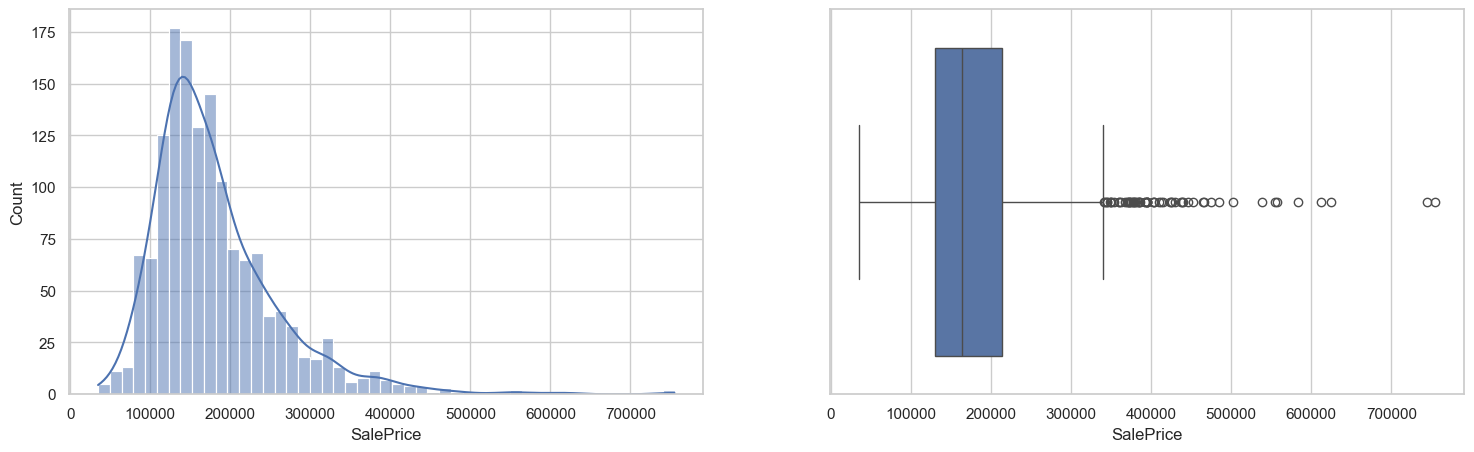

In [214]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

print("Target Columns:", TARGET_COL)
print("Target skewness:", train[TARGET_COL].skew())

sns.histplot(train[TARGET_COL], kde=True, ax=axes[0])
sns.boxplot(x=train[TARGET_COL], ax=axes[1])

plt.show()

### 3.2 Numeric analysis

- Distribution

GrLivArea


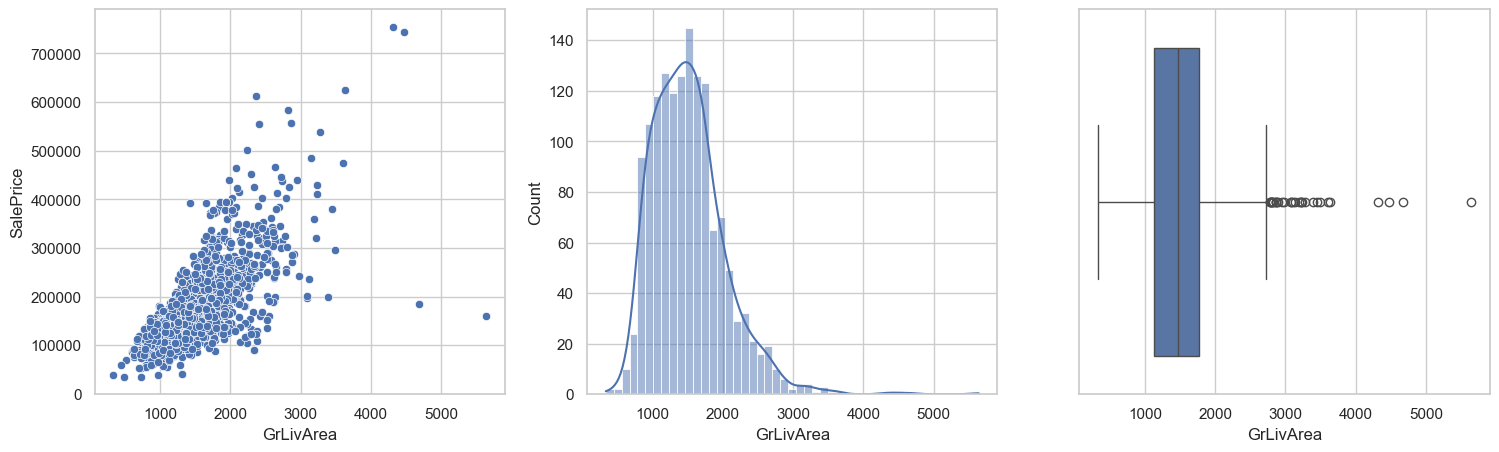

In [146]:
NUM_FEATURES = ['GrLivArea']
# NUM_FEATURES = NUM_COL.drop([ID_COL, TARGET_COL])

for feature in NUM_FEATURES:

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

    print(feature)

    sns.scatterplot(x=train[feature],y=train[TARGET_COL], ax=axes[0])
    sns.histplot(train[feature], kde=True, ax=axes[1])
    sns.boxplot(x=train[feature], ax=axes[2])

    # subfig = plt.figure(figsize=(18, 5))
    # sns.boxplot(x=pd.cut(train[feature], bins=50, precision=1), y=train[TARGET_COL])
    # plt.xticks(rotation=90)
    # plt.show()

    plt.show()

In [ ]:
for feature in NUM_FEATURES:
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(18, 5))

    print(feature)

    sns.boxplot(x=pd.cut(train[feature], bins=50, precision=1), y=train[TARGET_COL])

    plt.xticks(rotation=90)
    plt.show()


### 3.3 Categoric Analysis

- Distribution

MSZoning


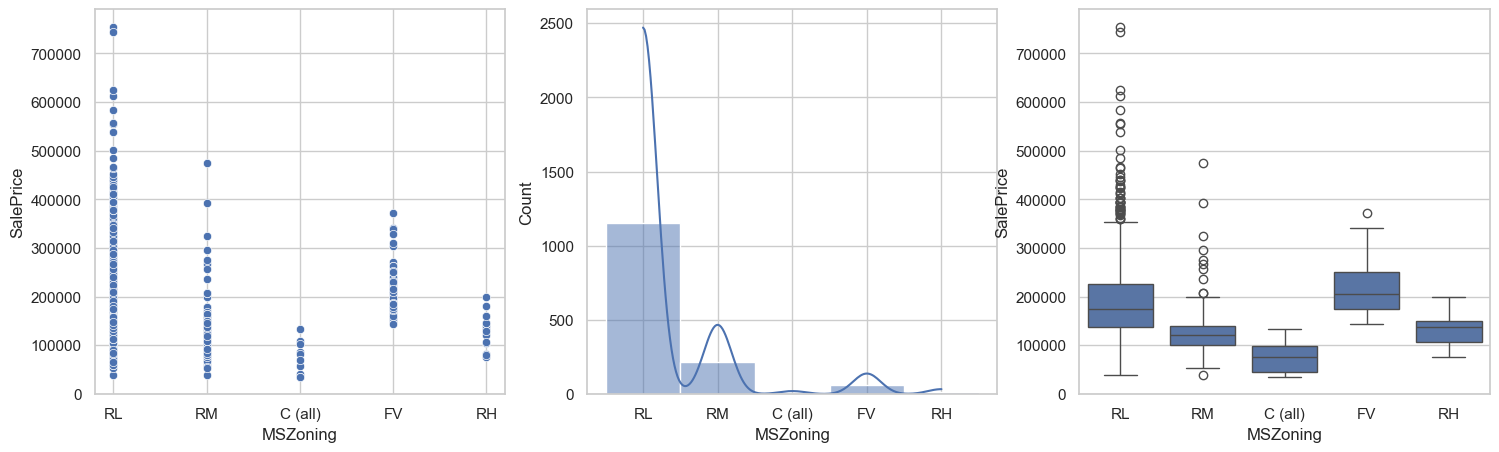

In [215]:
CAT_FEATURES = ['MSZoning']
# CAT_FEATURES = OBJ_COL

for feature in CAT_FEATURES:

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

    print(feature)

    sns.scatterplot(x=train[feature],y=train[TARGET_COL], ax=axes[0])
    sns.histplot(train[feature], kde=True, ax=axes[1])
    sns.boxplot(x=train[feature], y=train[TARGET_COL], ax=axes[2])

    plt.show()

### Correlative Analysis
- pearson
- spearman

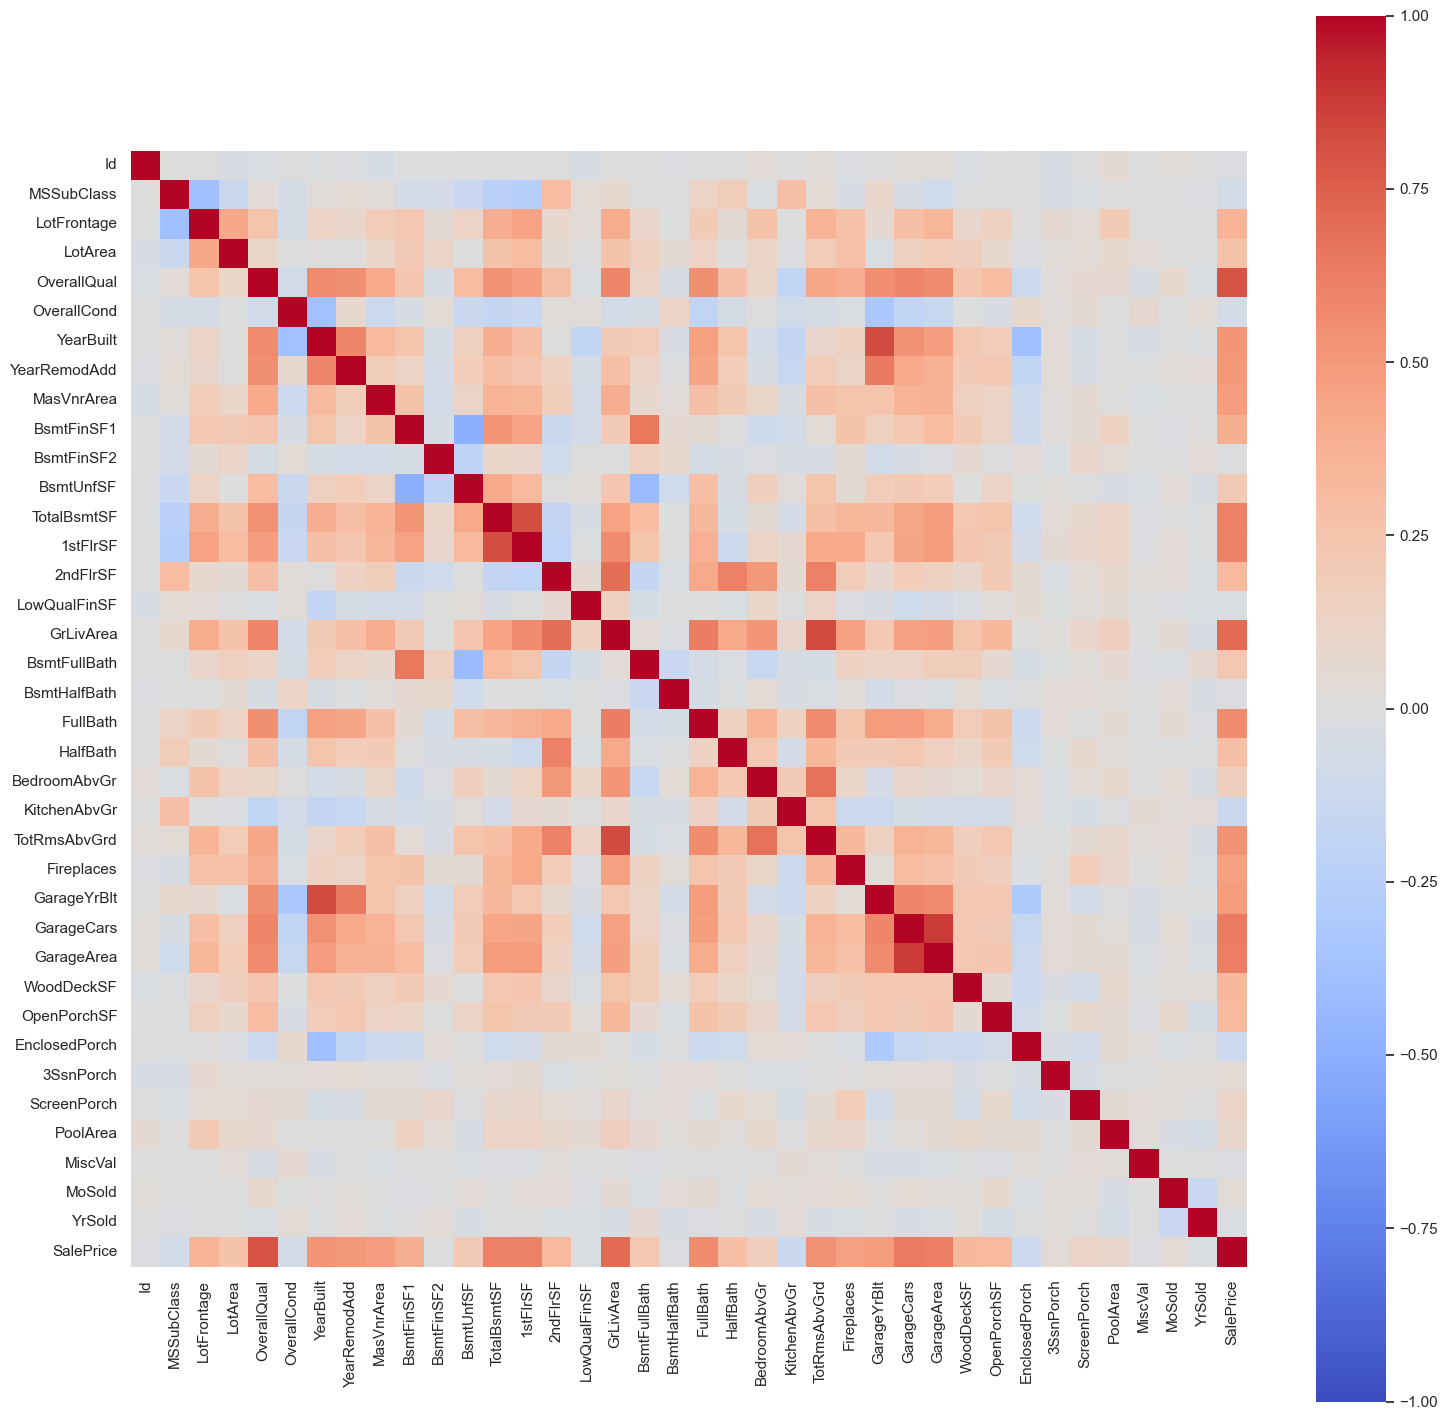

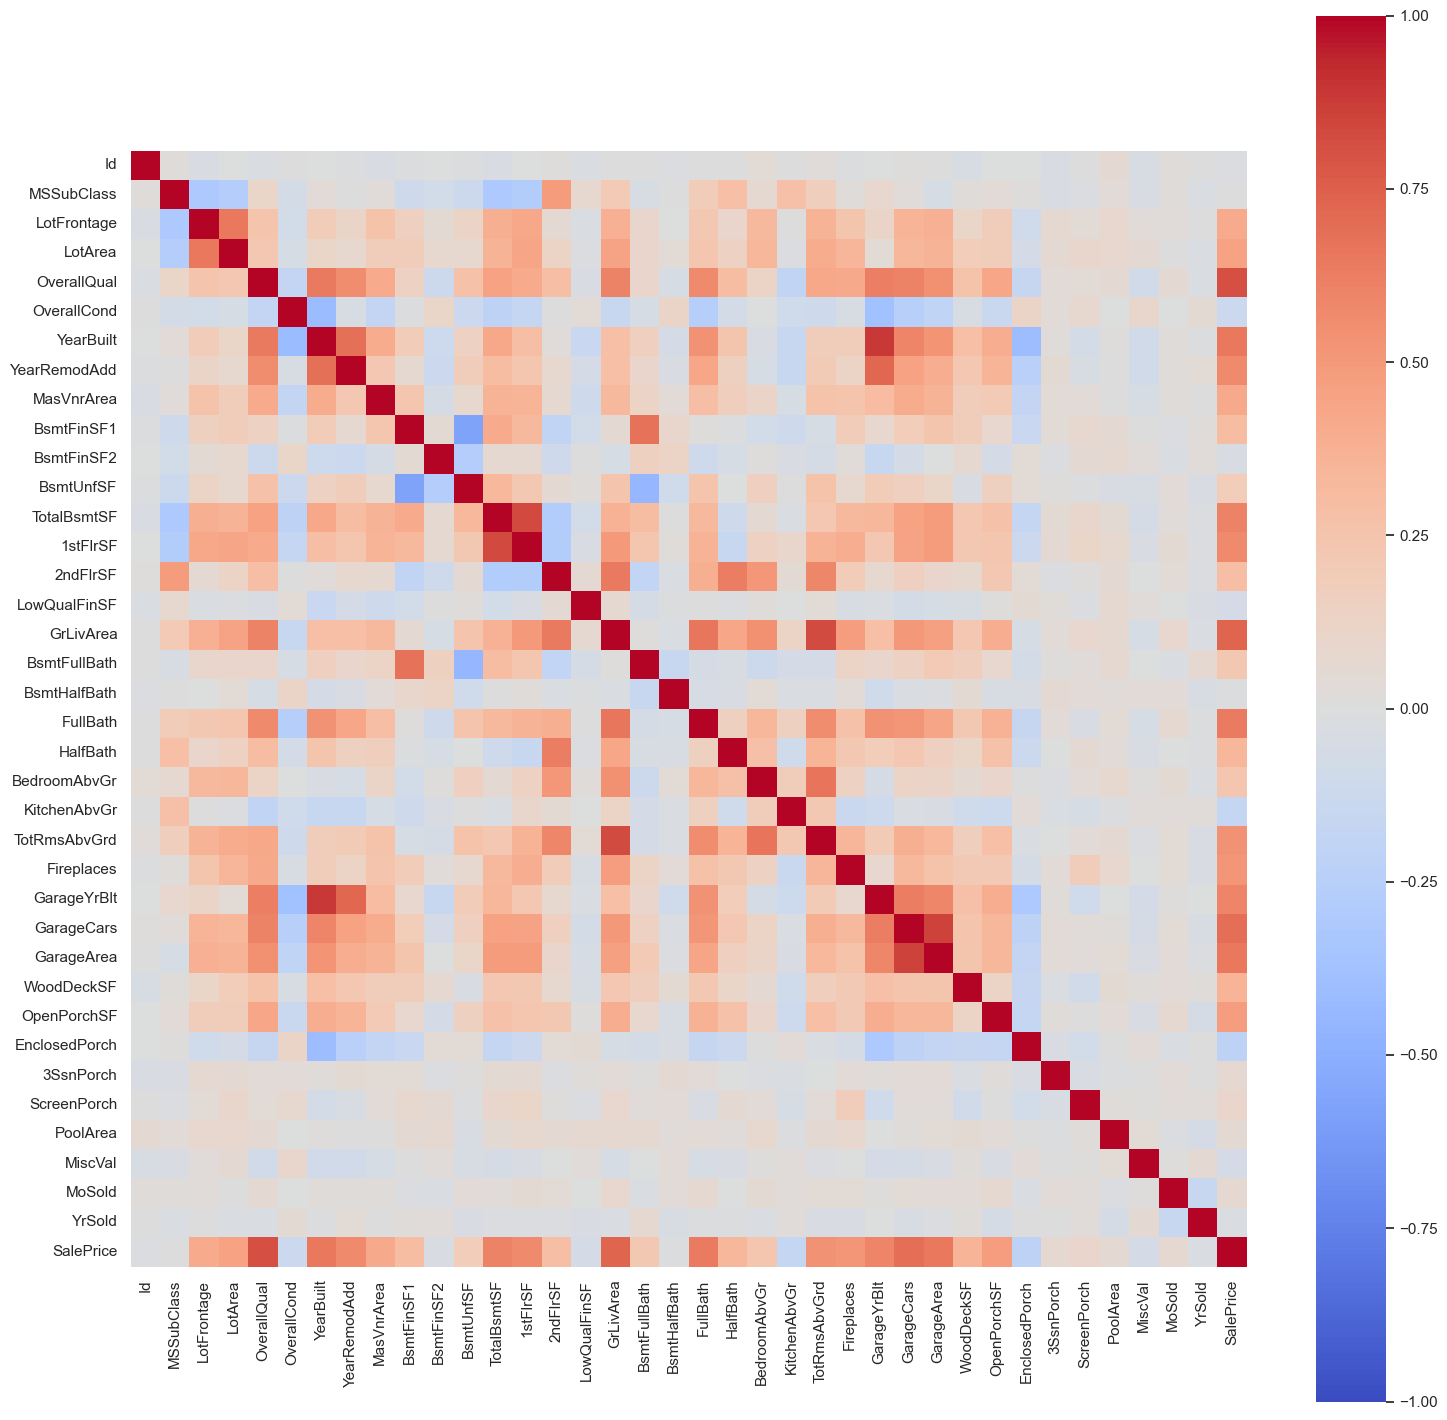

In [205]:
corr_pearson = train.corr(
    numeric_only=True,
    method="pearson",
)

corr_spearman = train.corr(
    numeric_only=True,
    method="spearman",
)

target_corr_pearson = corr_pearson[TARGET_COL]
high_pearson_features = target_corr_pearson[abs(target_corr_pearson) > 0.5].index

target_corr_spearman = corr_spearman[TARGET_COL]
high_spearman_features = target_corr_spearman[abs(target_corr_spearman) > 0.5].index

plt.figure(figsize=(18, 18))
sns.heatmap(corr_pearson, vmin=-1, vmax=1, annot=False, square=True, cmap="coolwarm")
plt.show()

plt.figure(figsize=(18, 18))
sns.heatmap(corr_spearman, vmin=-1, vmax=1, annot=False, square=True, cmap="coolwarm")
plt.show()

# display(corr_pearson[TARGET_COL].sort_values(ascending=False).head(10))
# display(corr_spearman[TARGET_COL].sort_values(ascending=False).head(10))


In [217]:
target_corr = pd.DataFrame({
    "Pearson": target_corr_pearson,
    "Spearman": target_corr_spearman,
    "Differ": target_corr_pearson - target_corr_spearman
})

display(target_corr.sort_values(by="Spearman", ascending=False).head(10))
display(target_corr.sort_values(by="Spearman", ascending=True).head(5))

,Pearson,Spearman,Differ
SalePrice,1.000000,1.000000,0.000000
OverallQual,0.790982,0.809829,-0.018847
GrLivArea,0.708624,0.731310,-0.022685
GarageCars,0.640409,0.690711,-0.050302
YearBuilt,0.522897,0.652682,-0.129784
GarageArea,0.623431,0.649379,-0.025947
FullBath,0.560664,0.635957,-0.075293
TotalBsmtSF,0.613581,0.602725,0.010855
GarageYrBlt,0.486362,0.593788,-0.107427
1stFlrSF,0.605852,0.575408,0.030444


,Pearson,Spearman,Differ
EnclosedPorch,-0.128578,-0.218394,0.089816
KitchenAbvGr,-0.135907,-0.164826,0.028918
OverallCond,-0.077856,-0.129325,0.051469
LowQualFinSF,-0.025606,-0.067719,0.042113
MiscVal,-0.021190,-0.062727,0.041537


## 4 Train/Valid Split

In [218]:
X = train.drop(columns=[ID_COL, TARGET_COL]).copy()
Y = train[TARGET_COL].copy()

X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("Y_train:", Y_train.shape)
print("Y_valid:", Y_valid.shape)

X_train: (1168, 79)
X_valid: (292, 79)
Y_train: (1168,)
Y_valid: (292,)


## 5 Feature Engineering (15 min) 特征工程

- Feature Selection
  - by correlation
  - by importance
- Feature Creation
- Feature Combination
  - Total/Sum/Count
- Feature Transformation
  - Log Transformation
  - Polynomial Transformation
  - Binning
- Feature Extraction
  - Date/Time Feature: Festival, Used time
  - Text Feature: description → vector(TF-IDF/embeddings)
  - Image Feature: pixel/color/shape


In [258]:
SELECTED_FEATURE = [
    "OverallQual",
    "OverallCond",

    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",

    "GarageCars",
    "GarageArea",

    "TotRmsAbvGrd",
    "BedroomAbvGr",
    "FullBath",

    "YearBuilt",
    "YearRemodAdd",

    "Neighborhood",

    "LotArea",
]

TRAIN_FEATURE = SELECTED_FEATURE.copy()

In [283]:
print("Missing report of selected features")
display(missing_report(train, columns=SELECTED_FEATURE))

print("Total duplicated rows:", train[SELECTED_FEATURE].duplicated(keep=False).sum())
display(duplicated_entities_report(train, SELECTED_FEATURE))

Missing report of selected features


,dtype,missing_count,missing_rate


Total duplicated rows: 11
Total duplicated entitis: 11


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
193,194,160,RM,24.0,2522,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,130000
690,691,120,RM,NaN,4426,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,141000
721,722,120,RM,NaN,4426,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,143000
736,737,90,RL,60.0,8544,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,93500
831,832,160,FV,30.0,3180,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,151000
850,851,120,RM,36.0,4435,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,WD,Normal,131500
1088,1089,160,RM,24.0,2522,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,137500
1090,1091,90,RL,60.0,8544,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,92900
1364,1365,160,FV,30.0,3180,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,144152
1422,1423,120,RM,37.0,4435,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2008,WD,Normal,136500


## 6 Preprocess (15 mins) 预处理

- Missing value handle: Numeric, Categoric
- Outlier handle: delete, replace, transform
- Feature Encoding
  - One-Hot Encoding
  - Ordinal Encoding
- Feature Scaling
  - Standardization: mean → 0, std → 1
  - Normalization: value → [0~1]

## 7 Model Training (30 mins) 模型训练

- Baseline Select
- Model Training
- Valid Predict

## 8 Evaluation (10 mins) 评估